# 旧版 GFlowNet 的 Conditional-N 设计动机

本 Notebook 使用两个固定的旧版无条件 GFlowNet run，复查表达式复杂度分布、Reward 动态和不同节点规模之间的探索分配。

- **主要证据**：`d521789d86de425794a9e871b42db586`，文法分层策略（grammar_hierarchical），观测到 110 个训练 step。
- **次要长期证据**：`8778d49870c244a6996e31aa49f40e45`，平坦策略（flat），观测到 768 个训练 step。

两个运行 始终分别统计，不合并样本、不计算 合并统计，也不使用绝对 奖励（Reward）比较模型优劣。所有结果均属于历史诊断证据，不作因果解释。

In [2]:
# 1｜固定配置
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def locate_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, current.parent):
        if (candidate / "factor_gfn").is_dir() and (candidate / "runs").is_dir():
            return candidate
    raise RuntimeError("无法从当前目录或其父目录定位项目根目录。")


PROJECT_ROOT = locate_project_root()
PRIMARY_RUN = PROJECT_ROOT / "runs" / "real_search" / "d521789d86de425794a9e871b42db586"
SECONDARY_RUN = PROJECT_ROOT / "runs" / "real_search" / "8778d49870c244a6996e31aa49f40e45"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "legacy_conditional_motivation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_PHASES = {"早期（1–28）": (1, 28), "后期（83–110）": (83, 110)}
SECONDARY_PHASES = {
    "第一阶段（1–192）": (1, 192),
    "第二阶段（193–384）": (193, 384),
    "第三阶段（385–576）": (385, 576),
    "第四阶段（577–768）": (577, 768),
}
PRIMARY_WINDOW_STEPS = 10
SECONDARY_WINDOW_STEPS = 48

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"项目根目录：{PROJECT_ROOT}")
print("主要证据：文法分层策略（grammar_hierarchical），110 步 历史片段")
print("次要证据：平坦策略（flat），768 步 长期稳健性证据")
print(f"输出目录：{OUTPUT_DIR}")

项目根目录：D:\实习\Gflownet因子挖掘
主要证据：文法分层策略（grammar_hierarchical），110 步 历史片段
次要证据：平坦策略（flat），768 步 长期稳健性证据
输出目录：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation


In [3]:
# 2｜读取并验证旧版数据
display(Markdown('''## 数据读取与最小一致性检查

`node_count` 表示实际生成的终止表达式节点数，不是目标 N，也不是 per-N optimizer update。只有 `valid=true` 的记录进入训练 batch；无效记录仍计入 生成请求。'''))


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def load_legacy_run(path: Path, role: str) -> dict:
    required = ["evaluations.jsonl", "training_stats.json", "run_metadata.json", "run_state.json"]
    missing = [name for name in required if not (path / name).is_file()]
    if missing:
        raise FileNotFoundError(f"{role} 缺少必要文件：{missing}")
    return {
        "role": role,
        "path": path,
        "evaluations": pd.read_json(path / "evaluations.jsonl", lines=True),
        "training_stats": read_json(path / "training_stats.json"),
        "metadata": read_json(path / "run_metadata.json"),
        "state": read_json(path / "run_state.json"),
    }


def validate_legacy_run(run: dict, expected_steps: int, expected_accepted: int) -> dict:
    evaluations = run["evaluations"]
    accepted = evaluations.loc[evaluations["valid"].eq(True)].copy()
    observed_steps = int(evaluations["logical_step"].max())

    if observed_steps != expected_steps:
        raise RuntimeError(f"{run['role']} 的 observed steps 为 {observed_steps}，预期为 {expected_steps}。")
    if len(accepted) != expected_accepted:
        raise RuntimeError(f"{run['role']} 的 accepted count 为 {len(accepted)}，预期为 {expected_accepted}。")
    if accepted["reward"].isna().any():
        raise RuntimeError(f"{run['role']} 存在 有效轨迹 reward 缺失。")
    if evaluations["structural_hash"].isna().any():
        raise RuntimeError(f"{run['role']} 存在 structural_hash 缺失。")
    if int(evaluations["node_count"].min()) != 1 or int(evaluations["node_count"].max()) != 15:
        raise RuntimeError(f"{run['role']} 的 node_count 范围不是 1–15。")
    if int(run["state"]["current_step"]) != expected_steps:
        raise RuntimeError(f"{run['role']} 的 run_state 与 evaluations 不一致。")

    return {
        "证据角色": run["role"],
        "观测步数": observed_steps,
        "生成请求数": len(evaluations),
        "有效轨迹数": len(accepted),
        "无效请求数": int((~evaluations["valid"].eq(True)).sum()),
        "节点数最小值": int(evaluations["node_count"].min()),
        "节点数最大值": int(evaluations["node_count"].max()),
        "有效 Reward 缺失数": int(accepted["reward"].isna().sum()),
        "结构哈希缺失数": int(evaluations["structural_hash"].isna().sum()),
    }


primary = load_legacy_run(PRIMARY_RUN, "主要证据")
secondary = load_legacy_run(SECONDARY_RUN, "次要长期证据")

validation_summary = pd.DataFrame([
    validate_legacy_run(primary, expected_steps=110, expected_accepted=880),
    validate_legacy_run(secondary, expected_steps=768, expected_accepted=6144),
])
display(validation_summary)
print("关键数量、Reward 完整性和 structural_hash 可用性检查通过。")

## 数据读取与最小一致性检查

`node_count` 表示实际生成的终止表达式节点数，不是目标 N，也不是 per-N optimizer update。只有 `valid=true` 的记录进入训练 batch；无效记录仍计入 生成请求。

,证据角色,观测步数,生成请求数,有效轨迹数,无效请求数,节点数最小值,节点数最大值,有效 Reward 缺失数,结构哈希缺失数
0,主要证据,110,1112,880,232,1,15,0,0
1,次要长期证据,768,6891,6144,747,1,15,0,0


关键数量、Reward 完整性和 structural_hash 可用性检查通过。


## 可视化一｜训练过程中的复杂度分布

**研究问题：**旧版无条件 GFlowNet 的有效生成结果是否随着训练逐渐集中到高复杂度 N？

主要证据比较早期与后期；次要证据按四个等长阶段比较。每一行都在本次运行、本阶段内归一化为 100%，不合并两个运行。

这里更准确的观察是：**复杂度分配集中到少数 N 区域**，而不是简单地说模型只偏好高复杂度。N=15 的集中可能与 `max_nodes` 边界或终止效应有关；N=7 的集中也值得保留观察，可能反映表达式结构偏好。

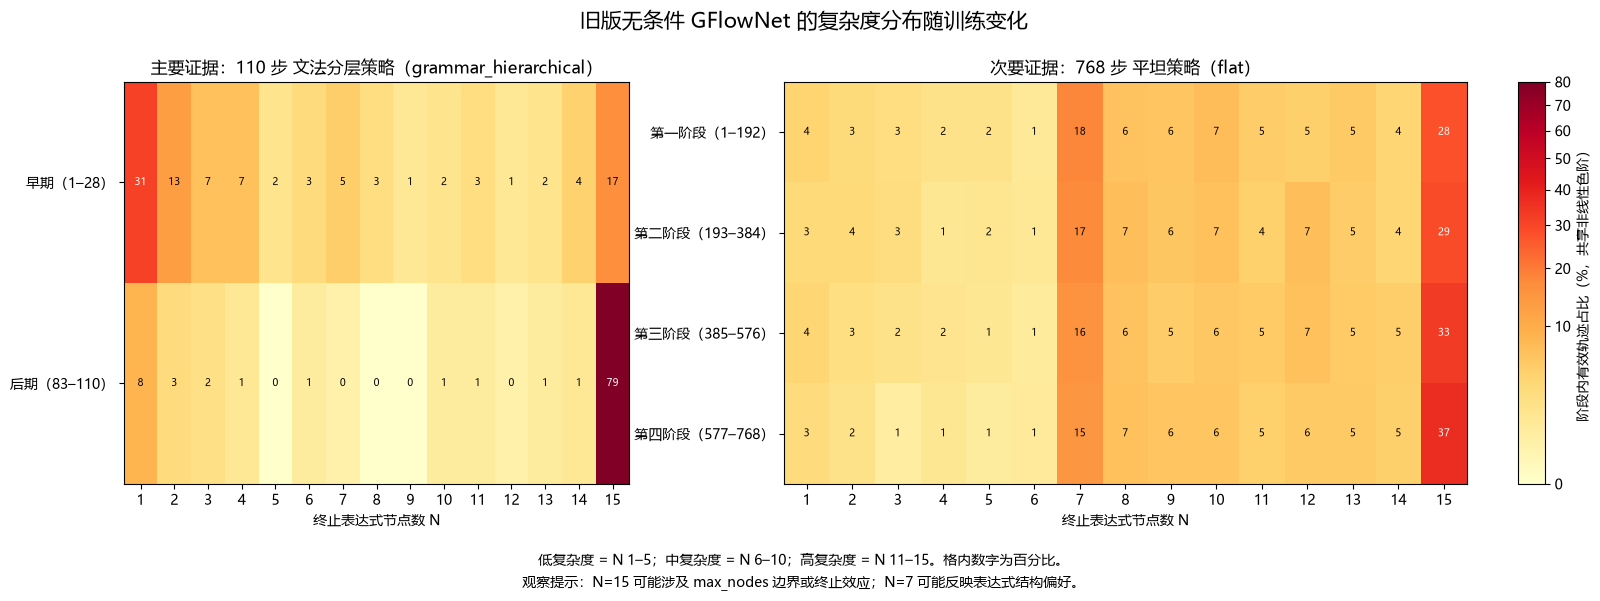

已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\primary_secondary_n_distribution.png


In [4]:
# 3｜可视化一：训练过程中的复杂度分布
from matplotlib.colors import PowerNorm
display(Markdown('''## 可视化一｜训练过程中的复杂度分布

**研究问题：**旧版无条件 GFlowNet 的有效生成结果是否随着训练逐渐集中到高复杂度 N？

主要证据比较早期与后期；次要证据按四个等长阶段比较。每一行都在本次运行、本阶段内归一化为 100%，不合并两个运行。

这里更准确的观察是：**复杂度分配集中到少数 N 区域**，而不是简单地说模型只偏好高复杂度。N=15 的集中可能与 `max_nodes` 边界或终止效应有关；N=7 的集中也值得保留观察，可能反映表达式结构偏好。'''))


def phase_distribution(evaluations: pd.DataFrame, phases: dict[str, tuple[int, int]]) -> pd.DataFrame:
    accepted = evaluations.loc[evaluations["valid"].eq(True)]
    rows = []
    for phase, (start, end) in phases.items():
        subset = accepted.loc[accepted["logical_step"].between(start, end)]
        counts = subset["node_count"].value_counts().reindex(range(1, 16), fill_value=0)
        shares = counts / counts.sum()
        if not np.isclose(shares.sum(), 1.0):
            raise RuntimeError(f"阶段 {phase} 的 N share 未归一化为 100%。")
        rows.append(pd.Series(shares.to_numpy(), index=range(1, 16), name=phase))
    return pd.DataFrame(rows)


primary_distribution = phase_distribution(primary["evaluations"], PRIMARY_PHASES)
secondary_distribution = phase_distribution(secondary["evaluations"], SECONDARY_PHASES)

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.0, 1.35]})
panels = [
    (axes[0], primary_distribution, "主要证据：110 步 文法分层策略（grammar_hierarchical）"),
    (axes[1], secondary_distribution, "次要证据：768 步 平坦策略（flat）"),
]
# 两个 panel 共享同一个非线性颜色规范：保持百分比颜色可比，同时增强中低占比区域的对比度。
color_norm = PowerNorm(gamma=0.45, vmin=0, vmax=80)
image = None
for axis, table, title in panels:
    image = axis.imshow(table.to_numpy() * 100, aspect="auto", cmap="YlOrRd", norm=color_norm)
    axis.set_xticks(range(15), labels=range(1, 16))
    axis.set_yticks(range(len(table.index)), labels=table.index)
    axis.set_xlabel("终止表达式节点数 N")
    axis.set_title(title)
    for row_index in range(table.shape[0]):
        for column_index in range(table.shape[1]):
            value = table.iat[row_index, column_index] * 100
            background = image.cmap(image.norm(value))
            luminance = 0.2126 * background[0] + 0.7152 * background[1] + 0.0722 * background[2]
            text_color = "white" if luminance < 0.52 else "black"
            axis.text(column_index, row_index, f"{value:.0f}", ha="center", va="center", fontsize=7, color=text_color)

# 使用独立 colorbar 轴，避免挤压右侧 panel 的 N=15 列。
colorbar_axis = fig.add_axes([0.92, 0.19, 0.016, 0.67])
colorbar = fig.colorbar(image, cax=colorbar_axis)
colorbar.set_label("阶段内有效轨迹占比（%，共享非线性色阶）")
fig.suptitle("旧版无条件 GFlowNet 的复杂度分布随训练变化", fontsize=15)
fig.text(0.5, 0.055, "低复杂度 = N 1–5；中复杂度 = N 6–10；高复杂度 = N 11–15。格内数字为百分比。", ha="center")
fig.text(0.5, 0.018, "观察提示：N=15 可能涉及 max_nodes 边界或终止效应；N=7 可能反映表达式结构偏好。", ha="center")
fig.subplots_adjust(left=0.10, right=0.89, top=0.86, bottom=0.19, wspace=0.26)

distribution_path = OUTPUT_DIR / "primary_secondary_n_distribution.png"
fig.savefig(distribution_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"已保存：{distribution_path}")

## 可视化二｜高复杂度集中程度 与 Reward 动态

**研究问题：**高复杂度集中程度 增强时，整体平均奖励 是否同步改善？

为避免逐 step 的 batch-8 噪声，使用预先固定的非重叠窗口：主要证据每 10 步 一个窗口，次要证据每 48 步 一个窗口。上下图共享训练进度，不使用双 y 轴，也不跨运行 比较 奖励（Reward）绝对值。

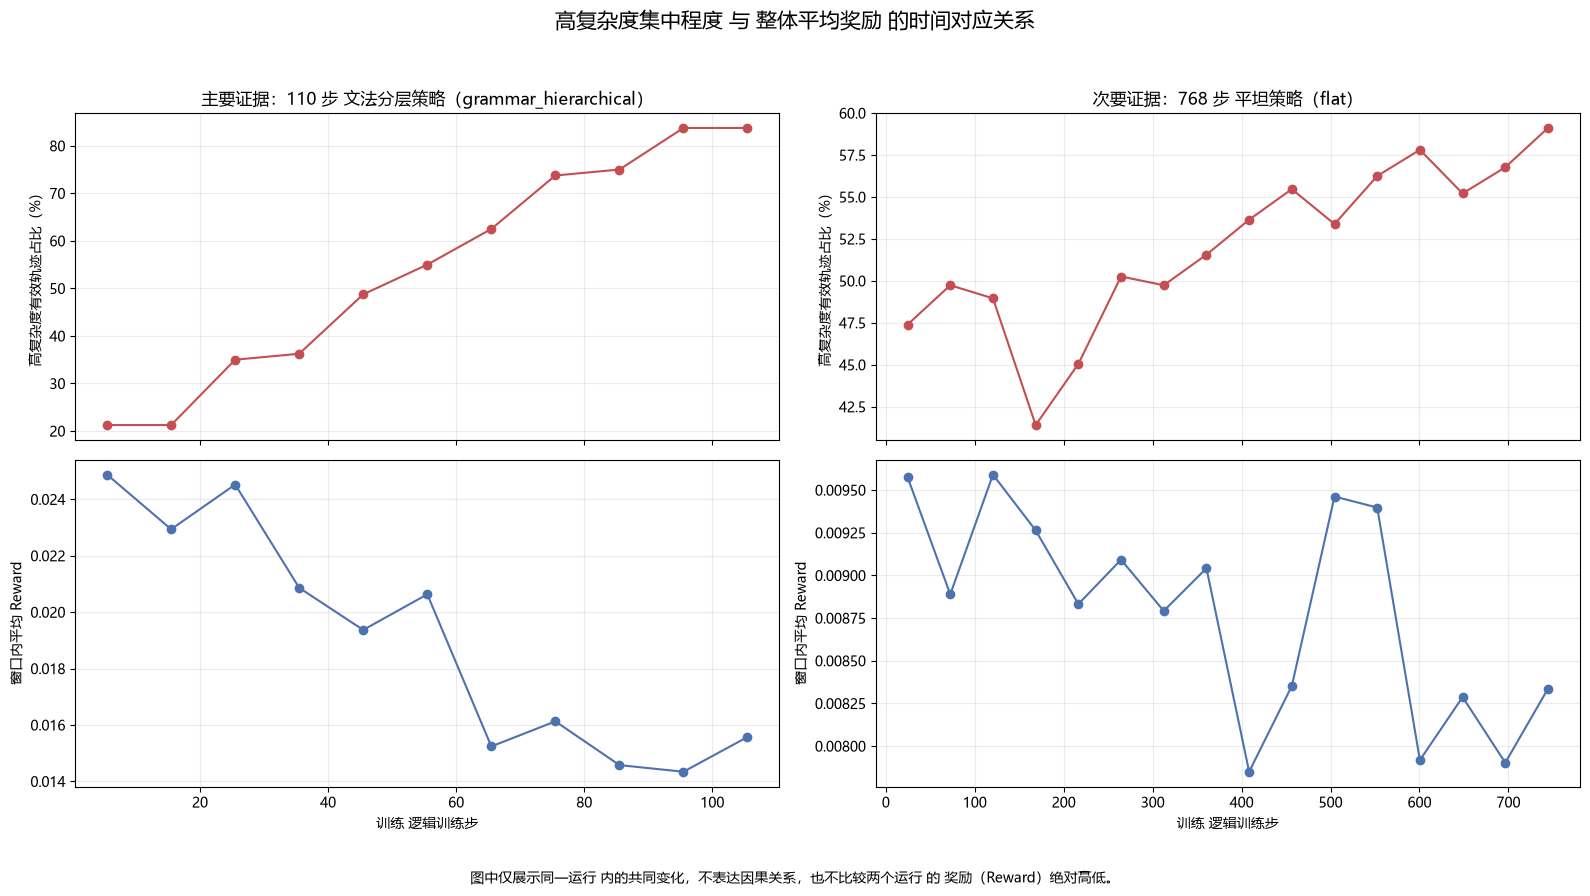

已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\concentration_reward_path.png


In [5]:
# 4｜可视化二：高复杂度集中程度 与 Reward 动态
display(Markdown(f'''## 可视化二｜高复杂度集中程度 与 Reward 动态

**研究问题：**高复杂度集中程度 增强时，整体平均奖励 是否同步改善？

为避免逐 step 的 batch-8 噪声，使用预先固定的非重叠窗口：主要证据每 {PRIMARY_WINDOW_STEPS} 步 一个窗口，次要证据每 {SECONDARY_WINDOW_STEPS} 步 一个窗口。上下图共享训练进度，不使用双 y 轴，也不跨运行 比较 奖励（Reward）绝对值。'''))


def window_dynamics(evaluations: pd.DataFrame, window_steps: int) -> pd.DataFrame:
    accepted = evaluations.loc[evaluations["valid"].eq(True)].copy()
    accepted["窗口编号"] = ((accepted["logical_step"] - 1) // window_steps).astype(int)
    grouped = accepted.groupby("窗口编号", sort=True)
    result = grouped.agg(
        起始步=("logical_step", "min"),
        结束步=("logical_step", "max"),
        平均奖励=("reward", "mean"),
        有效轨迹数=("reward", "size"),
    ).reset_index(drop=True)
    high_counts = grouped["node_count"].apply(lambda values: int((values >= 11).sum())).to_numpy()
    result["高复杂度占比"] = high_counts / result["有效轨迹数"].to_numpy()
    result["窗口中点"] = (result["起始步"] + result["结束步"]) / 2
    return result


primary_dynamics = window_dynamics(primary["evaluations"], PRIMARY_WINDOW_STEPS)
secondary_dynamics = window_dynamics(secondary["evaluations"], SECONDARY_WINDOW_STEPS)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex="col")
for column, (dynamics, title) in enumerate([
    (primary_dynamics, "主要证据：110 步 文法分层策略（grammar_hierarchical）"),
    (secondary_dynamics, "次要证据：768 步 平坦策略（flat）"),
]):
    axes[0, column].plot(dynamics["窗口中点"], dynamics["高复杂度占比"] * 100, marker="o", color="#c44e52")
    axes[0, column].set_ylabel("高复杂度有效轨迹占比（%）")
    axes[0, column].set_title(title)
    axes[0, column].grid(alpha=0.25)

    axes[1, column].plot(dynamics["窗口中点"], dynamics["平均奖励"], marker="o", color="#4c72b0")
    axes[1, column].set_ylabel("窗口内平均 Reward")
    axes[1, column].set_xlabel("训练 逻辑训练步")
    axes[1, column].grid(alpha=0.25)

fig.suptitle("高复杂度集中程度 与 整体平均奖励 的时间对应关系", fontsize=15)
fig.text(0.5, 0.01, "图中仅展示同一运行 内的共同变化，不表达因果关系，也不比较两个运行 的 奖励（Reward）绝对高低。", ha="center")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))

dynamics_path = OUTPUT_DIR / "concentration_reward_path.png"
fig.savefig(dynamics_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"已保存：{dynamics_path}")

## 可视化三｜不同 N 的探索分配

**研究问题：**不同 N 获得的绝对生成预算、有效轨迹预算和唯一结构覆盖是否均衡？

图中三个 share 都在各自运行 内归一化。CSV 另行保存 raw counts、重复访问、唯一结构率、mean valid reward 和 best valid reward。这里衡量的是观察到的绝对分配，不能解释为相对于各 N 完整搜索空间的覆盖率。

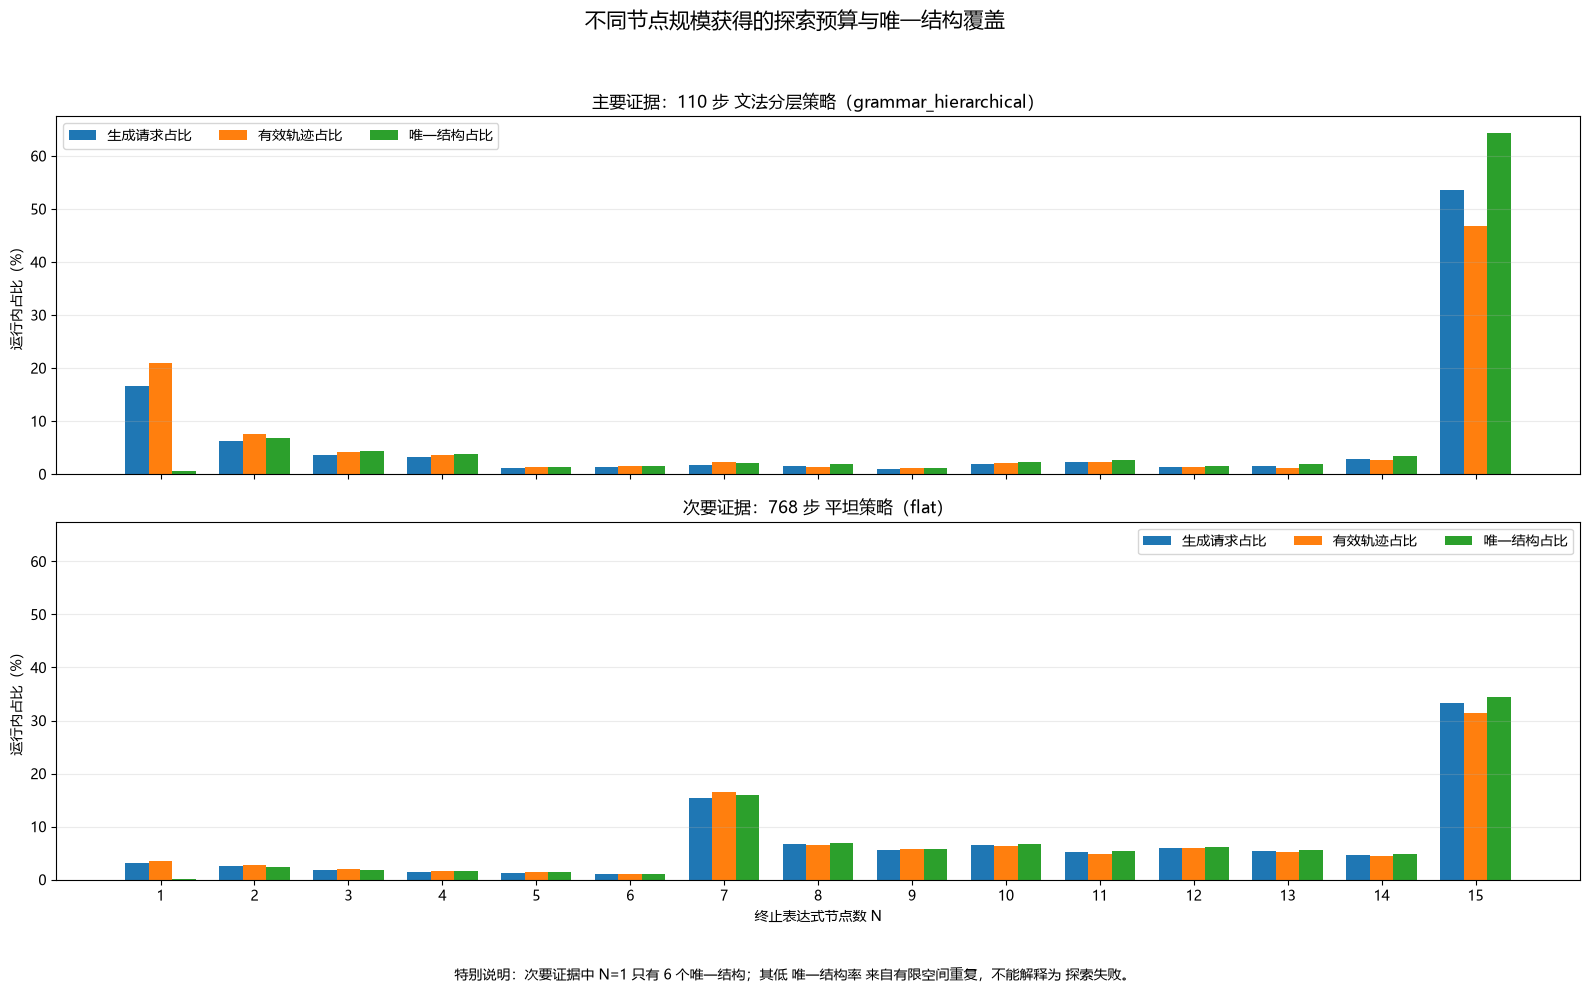

已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\exploration_allocation_by_n.png
已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\primary_exploration_by_n.csv
已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\secondary_exploration_by_n.csv


In [6]:
# 5｜可视化三：不同 N 的探索分配
display(Markdown('''## 可视化三｜不同 N 的探索分配

**研究问题：**不同 N 获得的绝对生成预算、有效轨迹预算和唯一结构覆盖是否均衡？

图中三个 share 都在各自运行 内归一化。CSV 另行保存 raw counts、重复访问、唯一结构率、mean valid reward 和 best valid reward。这里衡量的是观察到的绝对分配，不能解释为相对于各 N 完整搜索空间的覆盖率。'''))


def exploration_by_n(evaluations: pd.DataFrame) -> pd.DataFrame:
    accepted_all = evaluations.loc[evaluations["valid"].eq(True)]
    total_generated = len(evaluations)
    total_accepted = len(accepted_all)
    total_unique = evaluations["structural_hash"].nunique()
    rows = []
    for node_count in range(1, 16):
        generated = evaluations.loc[evaluations["node_count"].eq(node_count)]
        accepted = generated.loc[generated["valid"].eq(True)]
        unique_count = generated["structural_hash"].nunique()
        rows.append({
            "节点数N": node_count,
            "生成请求数": len(generated),
            "生成请求占比": len(generated) / total_generated,
            "有效轨迹数": len(accepted),
            "有效轨迹占比": len(accepted) / total_accepted,
            "唯一结构数": unique_count,
            "唯一结构占比": unique_count / total_unique,
            "重复访问数": len(generated) - unique_count,
            "唯一结构率": unique_count / len(generated) if len(generated) else np.nan,
            "有效Reward均值": accepted["reward"].mean(),
            "有效Reward最大值": accepted["reward"].max(),
        })
    return pd.DataFrame(rows)


primary_exploration = exploration_by_n(primary["evaluations"])
secondary_exploration = exploration_by_n(secondary["evaluations"])

primary_exploration_path = OUTPUT_DIR / "primary_exploration_by_n.csv"
secondary_exploration_path = OUTPUT_DIR / "secondary_exploration_by_n.csv"
primary_exploration.to_csv(primary_exploration_path, index=False, encoding="utf-8-sig")
secondary_exploration.to_csv(secondary_exploration_path, index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, sharey=True)
bar_width = 0.25
for axis, (table, title) in zip(axes, [
    (primary_exploration, "主要证据：110 步 文法分层策略（grammar_hierarchical）"),
    (secondary_exploration, "次要证据：768 步 平坦策略（flat）"),
]):
    x = table["节点数N"].to_numpy()
    axis.bar(x - bar_width, table["生成请求占比"] * 100, width=bar_width, label="生成请求占比")
    axis.bar(x, table["有效轨迹占比"] * 100, width=bar_width, label="有效轨迹占比")
    axis.bar(x + bar_width, table["唯一结构占比"] * 100, width=bar_width, label="唯一结构占比")
    axis.set_ylabel("运行内占比（%）")
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.25)
    axis.legend(ncol=3)

axes[-1].set_xticks(range(1, 16))
axes[-1].set_xlabel("终止表达式节点数 N")
fig.suptitle("不同节点规模获得的探索预算与唯一结构覆盖", fontsize=15)
fig.text(0.5, 0.01, "特别说明：次要证据中 N=1 只有 6 个唯一结构；其低 唯一结构率 来自有限空间重复，不能解释为 探索失败。", ha="center")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))

exploration_path = OUTPUT_DIR / "exploration_allocation_by_n.png"
fig.savefig(exploration_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"已保存：{exploration_path}")
print(f"已保存：{primary_exploration_path}")
print(f"已保存：{secondary_exploration_path}")

In [7]:
# 6｜表格四：跨运行 证据摘要
display(Markdown('''## 表格四｜跨运行 证据摘要

**研究问题：**两个 legacy run 在什么意义上提供方向一致的证据，又有哪些不可比之处？

下表只比较各 运行内的初始/最终阶段变化。绝不汇总两个运行 的 Reward、高复杂度占比 或轨迹数量。'''))


def phase_metrics(evaluations: pd.DataFrame, start: int, end: int) -> dict:
    accepted = evaluations.loc[
        evaluations["valid"].eq(True) & evaluations["logical_step"].between(start, end)
    ]
    return {
        "高复杂度占比": float(accepted["node_count"].ge(11).mean()),
        "N15占比": float(accepted["node_count"].eq(15).mean()),
        "平均奖励": float(accepted["reward"].mean()),
        "有效轨迹数": int(len(accepted)),
    }


primary_initial = phase_metrics(primary["evaluations"], 1, 28)
primary_final = phase_metrics(primary["evaluations"], 83, 110)
secondary_initial = phase_metrics(secondary["evaluations"], 1, 192)
secondary_final = phase_metrics(secondary["evaluations"], 577, 768)

# 与 A0 / A0.5 审计结果做数值锁定，避免阶段边界或 valid 口径漂移。
expected_checks = [
    (primary_initial["高复杂度占比"], 0.2678571429, "主要证据早期 高复杂度占比"),
    (primary_final["高复杂度占比"], 0.8258928571, "主要证据后期 高复杂度占比"),
    (primary_initial["平均奖励"], 0.023587, "主要证据早期 平均奖励"),
    (primary_final["平均奖励"], 0.015040, "主要证据后期 平均奖励"),
    (secondary_initial["高复杂度占比"], 0.46875, "次要证据 Q1 高复杂度占比"),
    (secondary_final["高复杂度占比"], 0.572265625, "次要证据 Q4 高复杂度占比"),
    (secondary_initial["平均奖励"], 0.009329788, "次要证据 Q1 平均奖励"),
    (secondary_final["平均奖励"], 0.008110926, "次要证据 Q4 平均奖励"),
]
for actual, expected, label in expected_checks:
    if not np.isclose(actual, expected, atol=5e-7):
        raise RuntimeError(f"{label} 与审计结果不一致：actual={actual}, expected={expected}")


def percent(value: float) -> str:
    return f"{value:.2%}"


def reward(value: float) -> str:
    return f"{value:.6f}"


summary_table = pd.DataFrame({
    "项目": [
        "证据角色", "策略", "配置 schema", "观测步数", "阶段定义",
        "初始 高复杂度 占比", "最终 高复杂度 占比", "高复杂度 占比变化",
        "初始 N=15 占比", "最终 N=15 占比",
        "初始平均奖励（Reward）", "最终平均奖励（Reward）", "运行内 奖励（Reward）变化",
        "主要限制",
    ],
    "主要证据": [
        "主要证据", "文法分层策略（grammar_hierarchical）", "factor_gfn.gfn_config.v5", "110", "早期 1–28；后期 83–110",
        percent(primary_initial["高复杂度占比"]), percent(primary_final["高复杂度占比"]),
        f"{(primary_final['高复杂度占比'] - primary_initial['高复杂度占比']) * 100:+.2f} 个百分点",
        percent(primary_initial["N15占比"]), percent(primary_final["N15占比"]),
        reward(primary_initial["平均奖励"]), reward(primary_final["平均奖励"]),
        percent(primary_final["平均奖励"] / primary_initial["平均奖励"] - 1),
        "仅观测到 110 步 前缀",
    ],
    "次要长期证据": [
        "次要长期稳健性证据", "平坦策略（flat）", "factor_gfn.gfn_config.v1", "768", "第一阶段 1–192；第四阶段 577–768",
        percent(secondary_initial["高复杂度占比"]), percent(secondary_final["高复杂度占比"]),
        f"{(secondary_final['高复杂度占比'] - secondary_initial['高复杂度占比']) * 100:+.2f} 个百分点",
        percent(secondary_initial["N15占比"]), percent(secondary_final["N15占比"]),
        reward(secondary_initial["平均奖励"]), reward(secondary_final["平均奖励"]),
        percent(secondary_final["平均奖励"] / secondary_initial["平均奖励"] - 1),
        "存在 平坦策略（flat） Token 数量结构偏置",
    ],
})

summary_path = OUTPUT_DIR / "cross_run_evidence_summary.csv"
summary_table.to_csv(summary_path, index=False, encoding="utf-8-sig")
display(summary_table)
print(f"已保存：{summary_path}")

output_paths = [
    distribution_path, dynamics_path, exploration_path,
    primary_exploration_path, secondary_exploration_path, summary_path,
]
missing_outputs = [str(path) for path in output_paths if not path.is_file()]
if missing_outputs:
    raise RuntimeError(f"以下输出文件未生成：{missing_outputs}")
print("全部 3 张核心图和 3 份 CSV 已生成；关键数值与 A0/A0.5 审计一致。")

## 表格四｜跨运行 证据摘要

**研究问题：**两个 legacy run 在什么意义上提供方向一致的证据，又有哪些不可比之处？

下表只比较各 运行内的初始/最终阶段变化。绝不汇总两个运行 的 Reward、高复杂度占比 或轨迹数量。

,项目,主要证据,次要长期证据
0,证据角色,主要证据,次要长期稳健性证据
1,策略,文法分层策略（grammar_hierarchical）,平坦策略（flat）
2,配置 schema,factor_gfn.gfn_config.v5,factor_gfn.gfn_config.v1
3,观测步数,110,768
4,阶段定义,早期 1–28；后期 83–110,第一阶段 1–192；第四阶段 577–768
5,初始 高复杂度 占比,26.79%,46.88%
6,最终 高复杂度 占比,82.59%,57.23%
7,高复杂度 占比变化,+55.80 个百分点,+10.35 个百分点
8,初始 N=15 占比,16.52%,27.60%
9,最终 N=15 占比,79.02%,36.98%


已保存：D:\实习\Gflownet因子挖掘\outputs\legacy_conditional_motivation\cross_run_evidence_summary.csv
全部 3 张核心图和 3 份 CSV 已生成；关键数值与 A0/A0.5 审计一致。


## 7｜Flat policy 的结构偏置说明

旧 平坦策略（flat） 的动作空间由 **6 个叶子 Token、106 个一元 Token 和 30 个二元 Token**组成，共 142 个具体 Token。策略对当前合法的具体 Token 直接进行 masked softmax；当 logits 接近时，各结构类别获得的总概率会受到该类别合法 Token 数量影响，叶子动作可能被大量一元、二元动作机械挤压。

这只是**机制说明，不是因果证据**。每个状态的合法 mask、剩余节点/深度预算以及训练后的 logits 都会改变实际概率；终态组合数量优势也可能同时存在。因此，不能把次要 运行的 高复杂度集中现象 唯一归因于 平坦策略（flat）。文字已经足够表达这一限制，本 Notebook 不额外生成可选的小图。

## 8｜对 Conditional-N 设计的解释

### 核心观察

1. 主要运行在观测到的 110 步前缀中，复杂度分配明显集中到少数 N 区域，尤其是 N=15 边界；同时，N=7 的中等复杂度集中也值得保留观察。
2. 更长的次要运行也呈现复杂度分配逐渐向少数 N 区域集中的现象，其中 N=15 与 N=7 均具有较明显的分配质量。
3. 两个运行的复杂度分配集中增强，都没有伴随整体平均奖励的同步改善。
4. 不同 N 获得的生成请求、有效轨迹和唯一表达式预算明显不均衡。

### 设计动机

旧版无条件 GFlowNet 在训练过程中逐渐表现出复杂度搜索质量向少数 N 区域集中的现象，但整体平均奖励并未同步改善，同时不同节点规模之间的探索预算明显不均衡。因此，后续将目标表达式节点数 N 显式作为条件变量，使不同复杂度空间能够获得可控且可比较的探索预算。该动机针对的是复杂度分配的可控性，并不等价于断言模型只偏好高复杂度表达式。

### 解释边界

这些结果属于历史诊断证据，而不是因果实验。主要运行仅观察到 110 步前缀；次要运行虽具有更长时间跨度，但存在平坦策略（flat）的 Token 数量结构偏置。N=15 的集中还可能与 `max_nodes` 边界或终止效应有关，N=7 的集中则可能反映表达式结构偏好。两个运行的架构、配置 schema、奖励提供器（Reward Provider）和优化合同也不完全相同。因此，它们支持 Conditional-N 的设计动机，但不能证明复杂度分配集中现象的唯一成因，也不能用于跨运行的绝对奖励或模型质量比较。